### Trimming

It will remove(trim) the last few chat messages based on token counts we specified

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, MessagesState, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

In [2]:
load_dotenv()

## LLM

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",  # or another Groq model you have access to
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.2,
        max_tokens=2500,
    )

llm= get_groq_llm()


In [9]:
MAX_TOKENS= 150

def chat(state: MessagesState):
    trimmed_messages= trim_messages(state['messages'],
                                    strategy='last',
                                    token_counter= count_tokens_approximately,
                                    max_tokens= MAX_TOKENS)
    result= llm.invoke(trimmed_messages)
    return {'messages':[result]}

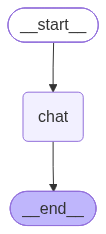

In [10]:
## Graph

graph= StateGraph(MessagesState)
graph.add_node('chat', chat)
graph.add_edge(START, 'chat')
graph.add_edge('chat', END)

app=graph.compile(checkpointer=InMemorySaver())
app

In [11]:
config= {"configurable":{"thread_id":"trim-demo"}}

while True:
    user_input= input("You: ")
    if user_input.lower() in ['exit', 'end']:
        break
    result= app.invoke({'messages':[{'role':'user', 'content':user_input}]}, config=config)
    print("Bot:", result['messages'][-1].content)

Bot: Hello! 👋 How can I help you today?
Bot: Nice to meet you, Sachin! How can I assist you today?
Bot: ## LangGraph Orchestrator – The “Brain” of Your LLM‑Powered Workflow

> **TL;DR**  
> The *Orchestrator* is LangGraph’s runtime engine.  
> It takes a **Graph** (nodes + edges), a **state** (the “world” you’re manipulating), and a **policy** (how to pick the next node).  
> It runs the graph, keeps the state in sync, handles retries, concurrency, and can be extended with custom schedulers, memory back‑ends, or external services.

---

## 1. What is LangGraph?

LangGraph is a framework for building **stateful, multi‑turn, multi‑LLM** applications.  
Think of it as a *workflow engine* where each node is a function (often an LLM prompt) and edges encode the flow of control.

```
[Start] → (Node A) → (Node B) → (Node C) → [End]
```

The *Orchestrator* is the engine that:

1. **Executes** nodes in the correct order.
2. **Maintains** the shared state (`GraphState`).
3. **Handles** retries,

### Deletion

It will delete the no of last chats messages based on message count we specify

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, MessagesState, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import RemoveMessage

In [2]:
load_dotenv()

## LLM

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",  # or another Groq model you have access to
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.2,
        max_tokens=2500,
    )

llm= get_groq_llm()


In [3]:
## Chat agent

def chat(state: MessagesState):
    response= llm.invoke(state['messages'])
    return {'messages':[response]}


In [ ]:
def cleanup(state: MessagesState):
    messages= state['messages']

    if len(messages)>6:
        to_remove= messages[:4]
        print(m.id for m in to_remove)
        return{'messages': [RemoveMessage(m.id) for m in to_remove]}
    return {}

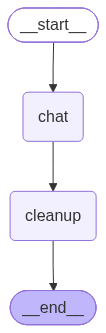

In [7]:
graph= StateGraph(MessagesState)
graph.add_node('chat', chat)
graph.add_node('cleanup', cleanup)

graph.add_edge(START, 'chat')
graph.add_edge('chat', 'cleanup')
graph.add_edge('cleanup', END)
app= graph.compile(checkpointer=InMemorySaver())
app

In [9]:
config= {"configurable":{"thread_id":"trim-demo"}}

while True:
    user_input= input('You: ')
    if user_input.lower() in ['end', 'exit']:
        break
    response= app.invoke({'messages': [{'role':'user', 'content':user_input}]}, config=config)
    print('bot:', response['messages'][-1].content)

bot: Hello! 👋 How can I help you today?
bot: Nice to meet you, Manirathinam! How can I assist you today?
bot: The current Prime Minister of India is **Narendra Modi**. He has been in office since May 26, 2014, leading the Bharatiya Janata Party (BJP) and serving as the head of the Indian government.
bot: The title “God of Cricket” is most famously associated with **Sachin Tendulkar**.  
He is widely regarded as one of the greatest batsmen in the history of the sport, and his record‑breaking career, record for most runs in both Tests and ODIs, and his iconic status in India and around the world earned him that nickname.
<generator object cleanup.<locals>.<genexpr> at 0x000001436E8B5600>
bot: **Sachin Tendulkar – International Centuries**

| Format | Centuries Scored |
|--------|------------------|
| **Test matches** | **100** |
| **One‑Day Internationals (ODIs)** | **49** |
| **Total (Test + ODI)** | **149** |

### Quick Highlights

- **Test Centuries** – 100 centuries in 200 matches, t

### Summerization


In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, MessagesState, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, RemoveMessage, BaseMessage

load_dotenv(override=True)

## LLM
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",  # or another Groq model you have access to
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.2,
        max_tokens=2500,
    )

llm= get_groq_llm()

In [2]:
class ChatState(MessagesState):
    summary: str

In [3]:
def chat(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])
    response = llm.invoke(messages)
    return {"messages": [response]}

In [4]:
def summarize(state: ChatState):
    prompt = "Summarize the conversation so far. in a way that you can include important details in future interactions. like name of the user, or the person you are talking & other important details."

    summary_input = state["messages"] + [HumanMessage(content=prompt)]
    response = llm.invoke(summary_input)

    to_delete = state["messages"][:4] 

    print([m.id for m in to_delete])  # print ids of messages to be removed

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in to_delete],
    }

def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

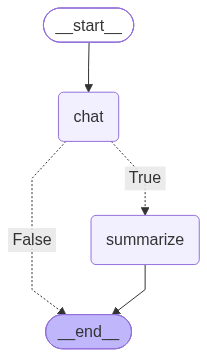

In [5]:
graph= StateGraph(ChatState)
graph.add_node('chat', chat)
graph.add_node('summarize', summarize)

graph.add_edge(START, 'chat')
graph.add_conditional_edges('chat', 
                            should_summarize,
                            {True: 'summarize', False:END})
graph.add_edge('summarize', END)
app= graph.compile(checkpointer=InMemorySaver())
app

In [6]:
config= {'configurable':{'thread_id':'summarize'}}

while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = app.invoke({"messages": [{"role": "user", "content": user_input}],"summary":""}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello! How can I help you today?
Bot: Nice to meet you, Manirathinam! How can I assist you today?
Bot: **Tamil Nadu – Gross Domestic Product (GDP)**  
*(latest available data – 2023‑24 fiscal year, where available)*  

| Fiscal Year | Nominal GDP (₹ trillion) | Real GDP (₹ trillion) | Growth Rate (YoY) | GDP per Capita (₹) | USD Equivalent (≈ ₹ 83 per $) |
|-------------|--------------------------|-----------------------|-------------------|--------------------|------------------------------|
| **2023‑24** | **≈ ₹ 4,200 trn** | **≈ ₹ 3,950 trn** | **+5.5 %** | **≈ ₹ 1,30,000** | **≈ $50 billion** |
| **2022‑23** | **≈ ₹ 3,950 trn** | **≈ ₹ 3,700 trn** | **+5.0 %** | **≈ ₹ 1,25,000** | **≈ $47 billion** |
| **2021‑22** | **≈ ₹ 3,700 trn** | **≈ ₹ 3,400 trn** | **+4.8 %** | **≈ ₹ 1,20,000** | **≈ $44 billion** |

> **Key Take‑aways**
> 1. **Tamil Nadu is the 4th largest state economy in India** (after Maharashtra, Uttar Pradesh, and Gujarat).  
> 2. The state’s GDP accounts for **≈ 